In [1]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from torch import nn
from data_processors import *
from scipy.stats import sem, t
import os
from tqdm import tqdm
from policies import DeepGaussianPolicy
from envs import PendulumEnv
from data_processors import KernelDataProcessor
import copy
import math
import imageio
import random
import pandas as pd
import seaborn as sns

/home/tedeschi_bpo/miniconda3/envs/RlEnv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

In [3]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{0.1}kl{0}_07_30-01_29_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_01_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{0.75}kl{0}_07_30-03_12_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{1.5}kl{0}_07_30-04_58_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{3}kl{0}_07_30-06_40_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_3_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{4}kl{0}_07_30-08_26_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_4_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{5}kl{0}_07_30-10_10_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00"
]

In [4]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['std 0.1', 'std 0.75', 'std 1.5', 'std 3', 'std 4', 'std 5']
print(len(all_performances))

6


In [5]:
def load_cost(trial_path):
    costs = []
    if os.path.isdir(trial_path):
        try:
            file_path = os.path.join(trial_path, "results.json")
            with open(file_path, 'r') as file:
                data = json.load(file)
                costs.append(data["cost"])
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"Errore nel leggere {file_path}: {e}")
    return np.array(costs)  

-0.07764696143583445
-0.27325991326577104
-0.7105682926183561
-2.992467074641638
-2.0278056022121684
-14.2826746267749


<Figure size 640x480 with 0 Axes>

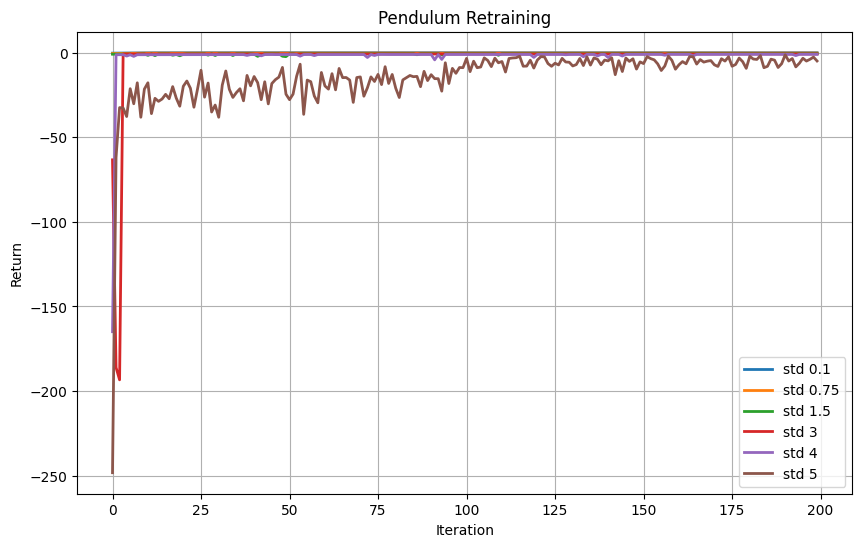

In [6]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Pendulum Retraining")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

In [7]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.25

NUM_EPISODES = 200

START = "down"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )

policies = [
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{0.1}kl{0}_07_30-01_29_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_01_noise_00/trial_0", 0.1],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{0.75}kl{0}_07_30-03_12_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{1.5}kl{0}_07_30-04_58_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1.5],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{3}kl{0}_07_30-06_40_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_3_noise_00/trial_0", 3],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{4}kl{0}_07_30-08_26_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_4_noise_00/trial_0", 4],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/std{5}kl{0}_07_30-10_10_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00/trial_0", 5],

    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/decaystd{3}kl{0}_07_30-16_41_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_3_noise_00/trial_0", 3],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/decaystd{4}kl{0}_07_30-18_42_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_4_noise_00/trial_0", 4],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_polvecchia/decaystd{5}kl{0}_07_30-20_46_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00/trial_0", 5]

    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/td{0.75}kl{0}_07_31-00_47_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75],
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/td{1}kl{0}_07_31-02_53_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1]

    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p0025std{0.75}kl{0}_07_31-13_32_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p0025std{1}kl{0}_07_31-15_16_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1],
]
data = []

for policy in policies :
    random.seed(SEED)
    np.random.seed(SEED)        
    pol = DeepGaussianPolicy(
                parameters=np.load(policy[0] +"/policy_params.npy"),
                output_size=a_dim,
                model=copy.deepcopy(net),
                model_desc=copy.deepcopy(model_desc),
                std_dev=STD_DEV,
                std_decay=0,
                std_min=1e-6
            )
    dp = KernelDataProcessor()

    all_episode_rewards = []
    for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
        episode_rewards = []
        done = False
        env.reset(options={"start": START}, seed = i)
        for t in range(HORIZON): # iterate over the steps until termination
            obs = env.state
            obs = dp.transform(obs)
            action = pol.draw_action(obs)
            obs, rew, done, _ = env.step(action)
            episode_rewards.append(rew * GAMMA ** t)
            if done:
                break
        all_episode_rewards.append(sum(episode_rewards))

    mean_episode_reward = np.mean(all_episode_rewards)
    std_episode_reward = np.std(all_episode_rewards)
    print("Mean reward:", mean_episode_reward,
            "Std reward:", std_episode_reward)


    # plt.plot(all_episode_rewards, linewidth=2, label="reward")
    # plt.title("Cartpole Reward")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()

    # plt.title("Pendulum Cost")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()
    # plt.legend()
    # plt.show
    mean_cost = np.mean(load_cost(policy[0]))

    data.append({
        'mean_reward' : mean_episode_reward,
        'std_reward' : std_episode_reward,
        'behavioural_std' : policy[1],
        'cost' : mean_cost

    })


100%|██████████| 200/200 [00:09<00:00, 20.25it/s]


Mean reward: -532.5173951558594 Std reward: 209.29977527115744


100%|██████████| 200/200 [00:09<00:00, 20.21it/s]


Mean reward: -533.2901963215296 Std reward: 209.19698075645255


In [5]:
df = pd.DataFrame(data)
df

,mean_reward,std_reward,behavioural_std,cost
0,-532.517395,209.299775,0.75,-1.262692
1,-533.290196,209.196981,1.00,-1.552649


simulazione policy imparata partendo dal verticale

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:09<00:00, 20.22it/s]


Mean reward: -532.5173951558594 Std reward: 209.29977527115744 Median -420.06540364552785


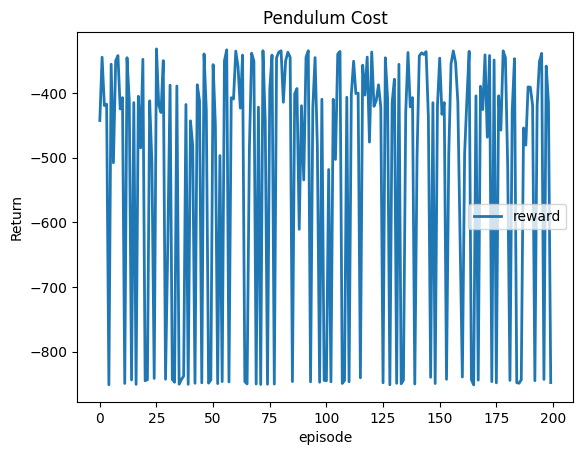

In [6]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.25

NUM_EPISODES = 200

START = "down"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p0025std{0.75}kl{0}_07_31-13_32_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()

all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    env.reset(options={"start": START}, seed = i)
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
        if done:
            break
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
median_episode_reward = np.median(all_episode_rewards)

print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward,
        "Median", median_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

plt.title("Pendulum Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/plots/friction03-03_down")

frames = []
env.reset(options={"start": START})
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    obs = dp.transform(obs)
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave("/home/tedeschi_bpo/learn_RL/gifs/pol5_v_down.gif", frames, duration=33)

In [ ]:
simualazione policy iniziale per confronto

100%|██████████| 200/200 [00:14<00:00, 13.94it/s]


Mean reward: -533.1199132036984 Std reward: 211.14480331958856 Median -419.9060937669959


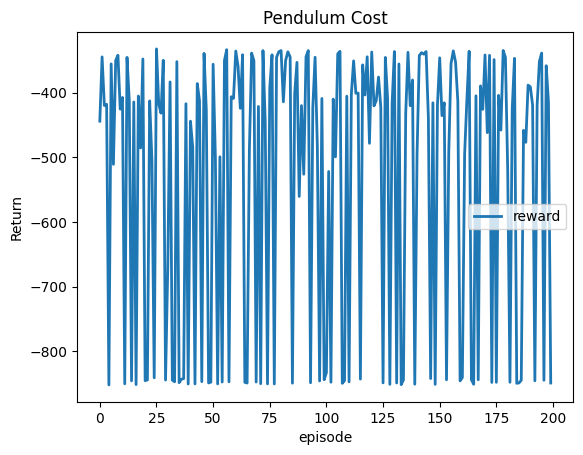

In [41]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.25

NUM_EPISODES = 200

START = "down"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()

all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    env.reset(options={"start": START}, seed = i)
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
        if done:
            break
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
median_episode_reward = np.median(all_episode_rewards)

print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward,
        "Median", median_episode_reward)


plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Cartpole Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()

plt.title("Pendulum Cost")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
plt.legend()
plt.show
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/plots/friction03-03_down")

frames = []
env.reset(options={"start": START})
for t in range(HORIZON): # iterate over the steps until termination
    obs = env.state
    obs = dp.transform(obs)
    action = pol.draw_action(obs)
    obs, rew, done, _ = env.step(action)
    frames.append( env.render())
    if done:
        break

imageio.mimsave("/home/tedeschi_bpo/learn_RL/gifs/pol_in_v_down.gif", frames, duration=33)

  0%|          | 1/5000 [00:00<09:10,  9.07it/s]

current mu = 0


 20%|██        | 1002/5000 [01:13<06:31, 10.21it/s]

current mu = 0.1


 40%|████      | 2003/5000 [02:22<03:26, 14.54it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4002/5000 [04:30<01:03, 15.61it/s]

current mu = 0.4


100%|██████████| 5000/5000 [05:34<00:00, 14.95it/s]


Mean reward: -4.215070064048651 Std reward: 42.128221874422266


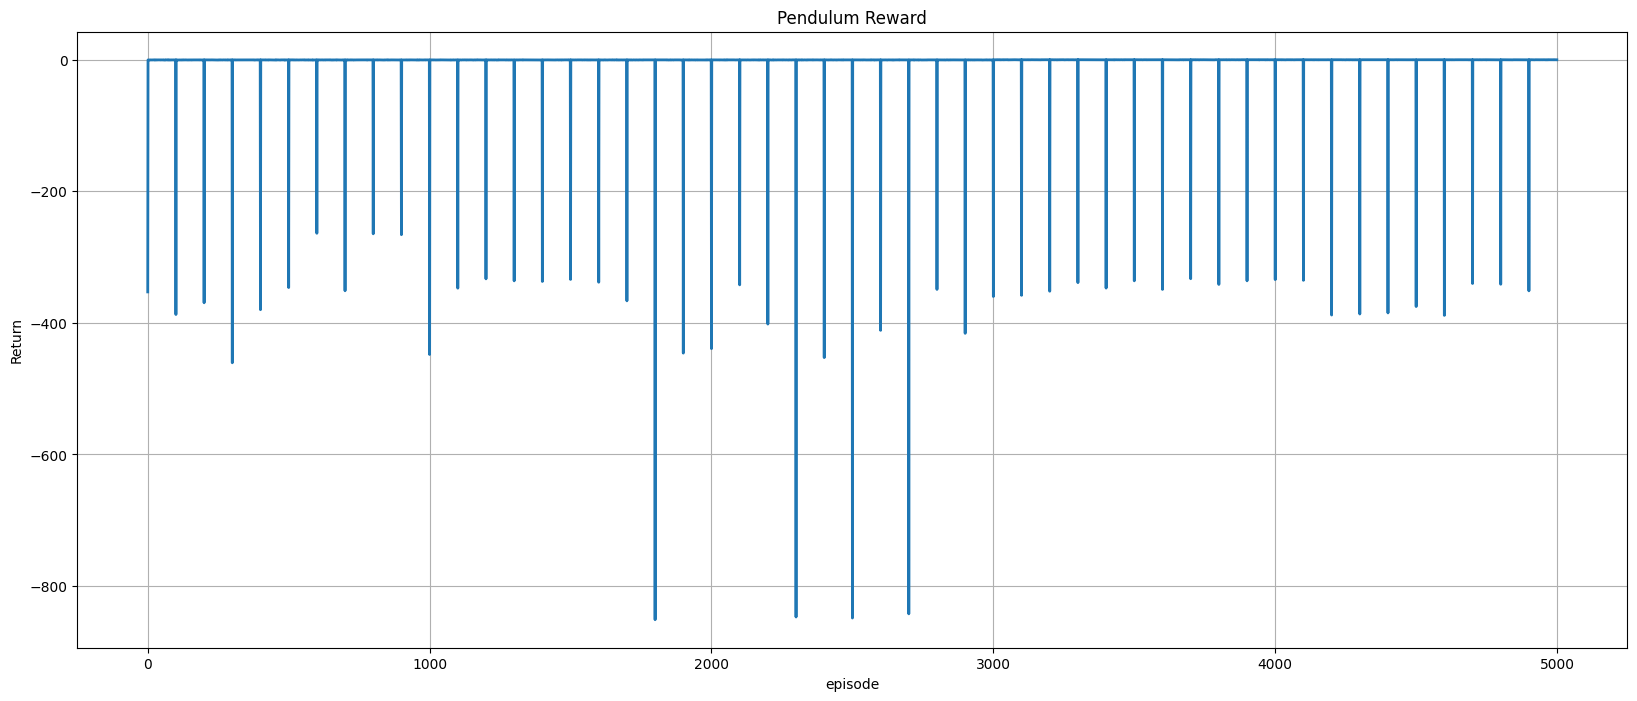

In [13]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/td{1}kl{0}_07_31-02_53_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")

